# 2. Data wrangling<a id='2_Data_wrangling'></a>

## 2.1 Contents<a id='2.1_Contents'></a>
* [2 Data wrangling](#2_Data_wrangling)
  * [2.1 Contents](#2.1_Contents)
  * [2.2 Introduction](#2.2_Introduction)
    * [2.2.1 Recap Of Data Science Problem](#2.2.1_Recap_Of_Data_Science_Problem)
  * [2.3 Imports](#2.3_Imports)
  * [2.4 Objectives](#2.4_Objectives)
  * [2.5 Load & Explore Datasets](#2.5_Load_&_Explore_Datasets)
  * [2.6 Save The Data](#2.6_Save_The_Data)
  * [2.7 Summary](#2.7_Summary)

## 2.2 Introduction<a id='2.2_Introduction'></a>

In this data wrangling step, we will be importing our data from key data sources, in our case, https://ourworldindata.org/ ,  making sure we have all the needed data points. We will then cleanse, restructure, reformat and narrow it down to get a consistent and reliable dataset, and also explore it to make sure the final data is ready for Exploratory Data Analysis phase.

### 2.2.1 Recap Of Data Science Problem<a id='2.2.1_Recap_Of_Data_Science_Problem'></a>

The purpose of this data science project is to predict and provide actionable insights on the impact of national economic activity, energy usage and demographic indicators within the context of increasingly plastic intensive global supply chains over the past many decades on global warming using carbon dioxide emission levels as our key indicator.

## 2.3 Imports<a id='2.3_Imports'></a>

In [1]:
#Import all relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from library.sb_utils import save_file

## 2.4 Objectives<a id='2.4_Objectives'></a>

* Ensuring we have the data needed to answer our problem
    * Identification of the required target value
    * Identification of potentially useful features
* Making sure we do not have fundamental issues with the data

## 2.5 Load & Explore Datasets <a id='2.5_Load_&_Explore_Datasets'></a>

In [2]:
# import country year grain annual co2 emissions csv file
co2_data = pd.read_csv('../data/raw/owid-co2-data.csv')

In [3]:
#Quick summary of the dataset
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

We will use the following columns for our analysis - country, year, iso_code, population, gdp, co2, co2_per_capita, co2_per_gdp, energy_per_capita and energy_per_gdp. co2 will be our target feature for this country, year level dataset while country, iso_code will be the categorical features with rest of them being numerical features.

Although our co2 dataset contains many additional variables, we decided not to use them because they are direct transformations or decompositions of the target variable and would compromise model validity (We will use derived features like co2_per_gdp for EDA phase only). Other fields have limited data availability or are highly collinear with our core features such as GDP, population, and energy/capita. To ensure we have clean, consistent, interpretable data and more accurate model predictions, we chose to focus on a concise, independent set of economic, demographic, and energy-related features.

That said, we will only keep the fields we need for our analysis from our co2 master dataset.

In [4]:
co2_data = co2_data[["country", "year", "iso_code", "population", "gdp", "co2", "co2_per_capita", "co2_per_gdp", "energy_per_capita", "energy_per_gdp"]]

In [5]:
#Call the info and describe method on the revised co2_data again to see a summary of the data
co2_data.info()
co2_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            50411 non-null  object 
 1   year               50411 non-null  int64  
 2   iso_code           42480 non-null  object 
 3   population         41167 non-null  float64
 4   gdp                15251 non-null  float64
 5   co2                29384 non-null  float64
 6   co2_per_capita     26509 non-null  float64
 7   co2_per_gdp        17528 non-null  float64
 8   energy_per_capita  10459 non-null  float64
 9   energy_per_gdp     7787 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 3.8+ MB


,year,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp
count,50411.000000,4.116700e+04,1.525100e+04,29384.000000,26509.000000,17528.000000,10459.000000,7787.000000
mean,1920.349249,6.017453e+07,3.300495e+11,420.227035,3.821369,0.397679,24325.863595,1.671652
std,65.859123,3.308433e+08,3.086383e+12,1972.092032,14.312866,0.754065,32302.447508,1.630303
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1875.000000,3.272140e+05,7.874038e+09,0.381000,0.171000,0.131750,2702.109500,0.764000
50%,1925.000000,2.291594e+06,2.743861e+10,5.081000,1.023000,0.264000,11883.904000,1.244000
75%,1975.000000,9.986553e+06,1.212627e+11,53.656500,4.327000,0.509000,35563.351500,2.053000
max,2024.000000,8.161973e+09,1.301126e+14,38598.578000,782.743000,82.599000,318559.688000,25.253000


In [6]:
#We will check all unique countries present in this data and make sure we only have countries and not continent or region level information
co2_data.country.unique()

array(['Afghanistan', 'Africa', 'Africa (GCP)', 'Albania', 'Algeria',
       'Andorra', 'Angola', 'Anguilla', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (GCP)', 'Asia (excl. China and India)', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Central America (GCP)', 'Chad',
       'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros',
       'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Domini

As we can see from the output above, there are continents and other ways like economic classification to describe regions present in the countries column ex. Africa, Asia, Upper-middle-income countries etc. To narrow this list down to countries as dictated in Our World in Data co2 dataset, we will have to check if they have the country level iso code present in the iso_code column.

In [7]:
#Checking entries in country column for which iso_code column has no code data
co2_data[co2_data.iso_code.isna()].country.unique()

array(['Africa', 'Africa (GCP)', 'Asia', 'Asia (GCP)',
       'Asia (excl. China and India)', 'Central America (GCP)', 'Europe',
       'Europe (GCP)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
       'European Union (27)', 'European Union (28)',
       'High-income countries', 'International aviation',
       'International shipping', 'Kosovo', 'Kuwaiti Oil Fires',
       'Kuwaiti Oil Fires (GCP)',
       'Least developed countries (Jones et al.)', 'Low-income countries',
       'Lower-middle-income countries', 'Middle East (GCP)',
       'Non-OECD (GCP)', 'North America', 'North America (GCP)',
       'North America (excl. USA)', 'OECD (GCP)', 'OECD (Jones et al.)',
       'Oceania', 'Oceania (GCP)', 'Ryukyu Islands',
       'Ryukyu Islands (GCP)', 'South America', 'South America (GCP)',
       'Upper-middle-income countries', 'World'], dtype=object)

It looks like only non country regions example continents, world etc. are missing country level iso codes.

In [8]:
#Let us make sure iso codes are only present for country level data
co2_data[~co2_data.iso_code.isna()].country.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Central African Republic', 'Chad',
       'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros',
       'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
     

From the above output it is clear that the values in country column with a valid iso code are actual countries and not continents/regions from our quick analysis above. So, we will narrow our co2 dataset further to only include actual countries data

In [9]:
co2_data = co2_data[~co2_data.iso_code.isna()]

In [10]:
#double checking to make sure the codes are 3 digit and we do not have entries with missing codes
co2_data.iso_code.isna().value_counts()
co2_data.iso_code.unique()

array(['AFG', 'ALB', 'DZA', 'AND', 'AGO', 'AIA', 'ATA', 'ATG', 'ARG',
       'ARM', 'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB',
       'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BES', 'BIH',
       'BWA', 'BRA', 'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR',
       'CAN', 'CPV', 'CAF', 'TCD', 'CHL', 'CHN', 'CXR', 'COL', 'COM',
       'COG', 'COK', 'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE',
       'COD', 'DNK', 'DJI', 'DMA', 'DOM', 'TLS', 'ECU', 'EGY', 'SLV',
       'GNQ', 'ERI', 'EST', 'SWZ', 'ETH', 'FRO', 'FJI', 'FIN', 'FRA',
       'PYF', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GRC', 'GRL', 'GRD',
       'GTM', 'GIN', 'GNB', 'GUY', 'HTI', 'HND', 'HKG', 'HUN', 'ISL',
       'IND', 'IDN', 'IRN', 'IRQ', 'IRL', 'ISR', 'ITA', 'JAM', 'JPN',
       'JOR', 'KAZ', 'KEN', 'KIR', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN',
       'LSO', 'LBR', 'LBY', 'LIE', 'LTU', 'LUX', 'MAC', 'MDG', 'MWI',
       'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MRT', 'MUS', 'MEX', 'FSM',
       'MDA', 'MCO',

In [11]:
#checking to make sure we do not have duplicate records for each country/year combination
duplicates= co2_data[co2_data.duplicated(subset=['country', 'year'], keep=False)]
print(duplicates)

Empty DataFrame
Columns: [country, year, iso_code, population, gdp, co2, co2_per_capita, co2_per_gdp, energy_per_capita, energy_per_gdp]
Index: []


There are no duplicates in co2_data set based on our quick check above.

In [12]:
#checking for country count by year for missing co2 values to narrow down the start year frame for analysis
countries_missing_co2_by_year = co2_data.groupby("year")["co2"].agg(lambda x: x.isna().sum()).reset_index(name="missing_co2_country_count")
countries_missing_co2_by_year.sort_values("year", ascending = False).head(50)

,year,missing_co2_country_count
274,2024,3
273,2023,3
272,2022,3
271,2021,3
270,2020,3
269,2019,3
268,2018,3
267,2017,3
266,2016,3
265,2015,3


The missing country count for annual CO2 data is in single digits starting 1990. So, we will potentially narrow the dataset down further to start at 1990. However, before we narrow it down further, let us import the remaining datasets needed for this analysis to check what timeframe data makes sense for our project

In [13]:
# import world,year level plastics production data csv file
global_plastic_prod_data = pd.read_csv('../data/raw/global-plastics-production.csv')

In [14]:
#Quick Summary Checks
global_plastic_prod_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 4 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Entity                                           69 non-null     object
 1   Code                                             69 non-null     object
 2   Year                                             69 non-null     int64 
 3   Annual plastic production between 1950 and 2019  69 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 2.3+ KB


In [15]:
global_plastic_prod_data.head()
global_plastic_prod_data.describe()

,Year,Annual plastic production between 1950 and 2019
count,69.000000,6.900000e+01
mean,1984.652174,1.375638e+08
std,20.460023,1.320418e+08
min,1950.000000,2.000000e+06
25%,1967.000000,2.300000e+07
50%,1985.000000,9.000000e+07
75%,2002.000000,2.310000e+08
max,2019.000000,4.597460e+08


In [16]:
#Checking to see if we have any global year records repeated more than once
global_plastic_prod_data.value_counts().sort_values(ascending=False)

Entity  Code      Year  Annual plastic production between 1950 and 2019
World   OWID_WRL  1950  2000000                                            1
                  1951  2000000                                            1
                  1952  2000000                                            1
                  1953  3000000                                            1
                  1954  3000000                                            1
                                                                          ..
                  2015  381000000                                          1
                  2016  400050000                                          1
                  2017  420052500                                          1
                  2018  441055125                                          1
                  2019  459746016                                          1
Name: count, Length: 69, dtype: int64

It looks like we do not have multiple entries for a year. Next, we will make sure none of the co2 global yearly values seem like an outlier. We will plot these values.

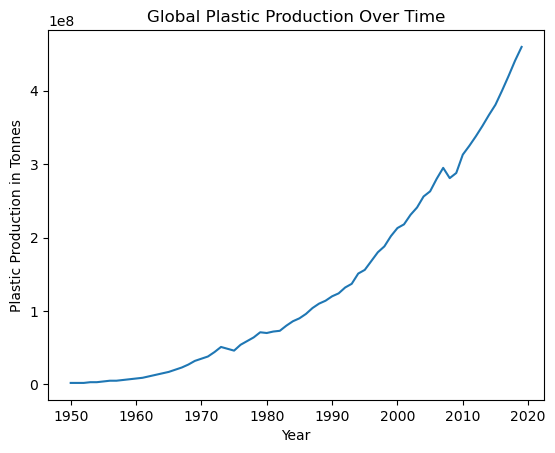

In [17]:
plt.plot(global_plastic_prod_data["Year"], global_plastic_prod_data["Annual plastic production between 1950 and 2019"])
plt.title("Global Plastic Production Over Time")
plt.xlabel("Year")
plt.ylabel("Plastic Production in Tonnes")
plt.show()

Looking at the graph above, we do not see any obvious outliers. Next, we will rename the columns and convert plastic production data to million tonnes for better readability.

In [18]:
global_plastic_prod_data["Annual plastic production between 1950 and 2019"] = global_plastic_prod_data["Annual plastic production between 1950 and 2019"] / 1000000

In [19]:
global_plastic_prod_data = global_plastic_prod_data.rename(columns = {"Entity" : "Region", "Annual plastic production between 1950 and 2019" : "Total_Plastic_Production_Million_Tonnes"})

In [20]:
global_plastic_prod_data.head()
global_plastic_prod_data.describe()

,Year,Total_Plastic_Production_Million_Tonnes
count,69.000000,69.000000
mean,1984.652174,137.563821
std,20.460023,132.041805
min,1950.000000,2.000000
25%,1967.000000,23.000000
50%,1985.000000,90.000000
75%,2002.000000,231.000000
max,2019.000000,459.746016


From the observations made for the 2 datasets above regarding what timeframe seems to have the most data, it makes sense to narrow our dataset timeframe for our main co2 data table from 1990-2019 since we do not have data past 2019 in global plastics dataset and most countries seems to have annual co2 emissions data starting 1990 in co2 emissions dataset

In [21]:
#Filtering co2 master data set further to get a 30 year timeframe with most co2 datapoints available for our analysis
co2_data = co2_data[(co2_data["year"] > 1989) & (co2_data["year"] < 2020)]
co2_data.info()
co2_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6540 entries, 240 to 50405
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            6540 non-null   object 
 1   year               6540 non-null   int64  
 2   iso_code           6540 non-null   object 
 3   population         6480 non-null   float64
 4   gdp                4918 non-null   float64
 5   co2                6433 non-null   float64
 6   co2_per_capita     6377 non-null   float64
 7   co2_per_gdp        4917 non-null   float64
 8   energy_per_capita  6030 non-null   float64
 9   energy_per_gdp     4867 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 562.0+ KB


,year,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp
count,6540.000000,6.480000e+03,4.918000e+03,6433.000000,6377.000000,4917.000000,6030.000000,4867.000000
mean,2004.500000,3.033768e+07,4.620885e+11,132.355042,5.090949,0.357906,24322.411845,1.579217
std,8.656103,1.222436e+08,1.576232e+12,631.374443,8.118595,1.220326,34125.872193,1.512807
min,1990.000000,5.430000e+02,2.571720e+08,0.000000,0.000000,0.020000,0.000000,0.078000
25%,1997.000000,6.281355e+05,1.792250e+10,0.787000,0.677000,0.153000,2617.627500,0.752000
50%,2004.500000,5.388208e+06,5.714414e+10,6.523000,2.678000,0.249000,10972.207500,1.198000
75%,2012.000000,1.915978e+07,2.790671e+11,53.479000,7.022000,0.402000,33304.551750,1.927000
max,2019.000000,1.423520e+09,2.363194e+13,10713.515000,364.791000,82.599000,318559.688000,23.021000


In [22]:
missing_data = pd.concat([co2_data.isnull().sum(), 100 * co2_data.isnull().mean()], axis=1)
missing_data.columns=['count', '%']
missing_data.sort_values(by=['count','%'], ascending=[False,False])

,count,%
energy_per_gdp,1673,25.581040
co2_per_gdp,1623,24.816514
gdp,1622,24.801223
energy_per_capita,510,7.798165
co2_per_capita,163,2.492355
co2,107,1.636086
population,60,0.917431
country,0,0.000000
year,0,0.000000
iso_code,0,0.000000


All columns associated with gdp seem to have the most missing data ~25%. Let us inspect the gdp column for the countries missing these values.

In [23]:
missing_gdp_data = co2_data[co2_data.gdp.isna()]
result = missing_gdp_data.groupby('country').agg(year_count = ('year','count'), avg_population = ('population','mean')).sort_values('avg_population', ascending=False)
result['avg_population'] = result['avg_population'].round(0)
print(result)

                                  year_count  avg_population
country                                                     
Sudan                                     30      31776474.0
Somalia                                   30      10519737.0
South Sudan                               30       7767335.0
Papua New Guinea                          30       6553766.0
Eritrea                                   30       2568011.0
United Arab Emirates                       2       2060684.0
East Timor                                30        989825.0
Fiji                                      30        864122.0
Guyana                                    30        760125.0
Bhutan                                    30        651658.0
Suriname                                  30        508190.0
Macao                                     30        500013.0
Solomon Islands                           30        496194.0
Brunei                                    30        354018.0
Bahamas                 

In [24]:
result = missing_gdp_data.groupby('country').agg(year_count = ('year','count'), max_co2_emissions = ('co2','max')).sort_values('max_co2_emissions', ascending=False)
result['max_co2_emissions'] = result['max_co2_emissions'].round(0)
print(result)

                                  year_count  max_co2_emissions
country                                                        
United Arab Emirates                       2               58.0
Sudan                                     30               22.0
Brunei                                    30               10.0
Papua New Guinea                          30                8.0
Curacao                                   30                7.0
New Caledonia                             30                6.0
Suriname                                  30                3.0
Aruba                                     30                3.0
Guyana                                    30                3.0
Bahamas                                   30                3.0
Maldives                                  30                2.0
Macao                                     30                2.0
South Sudan                               30                2.0
Bhutan                                  

Except United Arab Emirates which has only 2 years of missing data, all the remaining countries have no gdp data in our source dataset across the 30 year study period for our analysis. Most of these countries do not have reliable gdp data available readily due to them being conflict affected countries or having smaller populations and economies or being offshore islands that are part of a bigger country and hence do not have an independent economy per Our World in Data (2024) and World Bank (2024) website.

Our target feature CO2 emission values are also much lower than the avg co2 emissions in the dataset for countries missing all 30 years of gdp data.

We will go ahead and exclude countries that are missing all 30 years of gdp data for the reasons stated above.

In [25]:
no_gdp_countries = result[result.year_count == 30]

print("countries impacted : ", len(no_gdp_countries))

countries impacted :  54


In [26]:
co2_data=co2_data[~co2_data['country'].isin(no_gdp_countries.index)]

In [27]:
#Checking to make sure countries missing gdp for all 30 years were removed
co2_data.isnull().mean().sort_values(ascending=False)
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4920 entries, 240 to 50405
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            4920 non-null   object 
 1   year               4920 non-null   int64  
 2   iso_code           4920 non-null   object 
 3   population         4920 non-null   float64
 4   gdp                4918 non-null   float64
 5   co2                4919 non-null   float64
 6   co2_per_capita     4919 non-null   float64
 7   co2_per_gdp        4917 non-null   float64
 8   energy_per_capita  4869 non-null   float64
 9   energy_per_gdp     4867 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 422.8+ KB


CO2 is our key target indicator variable so it is important to make sure we have very few missing data records for it.
As we can see from the summary above, ~98.4% of the records have co2 values present. Let us inspect the ones that do not have the values.

In [28]:
missing_co2_data = co2_data[co2_data.co2.isna()]

In [29]:
missing_co2_data.groupby('country').agg(year_count = ('year','count')).sort_values('year_count', ascending=False)

,year_count
country,
Namibia,1


In [30]:
co2_data[co2_data['country']=='Namibia']

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp
31577,Namibia,1990,NAM,1369309.0,7.363139e+09,NaN,NaN,NaN,7418.709,1.380
31578,Namibia,1991,NAM,1415689.0,7.919429e+09,1.044,0.738,0.132,3812.350,0.682
31579,Namibia,1992,NAM,1461324.0,8.581728e+09,1.140,0.780,0.133,3436.283,0.585
31580,Namibia,1993,NAM,1508698.0,8.429493e+09,1.374,0.911,0.163,4185.706,0.749
31581,Namibia,1994,NAM,1556315.0,9.059012e+09,1.557,1.001,0.172,3868.406,0.665
31582,Namibia,1995,NAM,1602181.0,9.444540e+09,1.619,1.011,0.171,4494.408,0.762
31583,Namibia,1996,NAM,1646107.0,9.761026e+09,1.718,1.044,0.176,4540.366,0.766
31584,Namibia,1997,NAM,1689274.0,1.018793e+10,1.814,1.074,0.178,4542.339,0.753
31585,Namibia,1998,NAM,1732747.0,1.053912e+10,1.865,1.076,0.177,4501.538,0.740
31586,Namibia,1999,NAM,1776371.0,1.090978e+10,1.740,0.980,0.160,6051.055,0.985


We only have one missing year record for co2 emissions for Namibia which should not impact our analysis.

Next, we will create another summary table for co2 and plastic data at global, year level aggregation. 

In [31]:
# Combined summary table for CO2 emissions + plastics production at world, year grain from 1990 to 2019
# We will first aggregate CO2 dataset at world/year level for all metrics - co2, population, gdp, co2 per capita, co2 per gdp, energy per capita and energy per gdp

co2_global_data =(co2_data.groupby("year").agg(total_co2_mt = ("co2","sum"), 
                                               population_global = ("population","sum"), 
                                               gdp_global = ("gdp","sum"), 
                                               co2_per_capita_global = ("co2_per_capita", lambda x: (x*co2_data.loc[x.index, "population"]).sum()/co2_data.loc[x.index,"population"].sum()),
                                               energy_per_capita_global = ("energy_per_capita", lambda x: (x*co2_data.loc[x.index, "population"]).sum()/co2_data.loc[x.index,"population"].sum()),
                                               co2_per_gdp_global = ("co2_per_gdp", lambda x: (x*co2_data.loc[x.index, "gdp"]).sum()/co2_data.loc[x.index,"gdp"].sum()),
                                               energy_per_gdp_global = ("energy_per_gdp", lambda x: (x*co2_data.loc[x.index, "gdp"]).sum()/co2_data.loc[x.index,"gdp"].sum())
                                              ).reset_index())
assert co2_global_data["year"].is_unique
assert co2_global_data.isna().sum().sum()==0

In [32]:
#We will convert global population to millions and gdp_global to trillions for better readability
co2_global_data["population_global"] = co2_global_data["population_global"] /1000000
co2_global_data["gdp_global"] = co2_global_data["gdp_global"] /1000000000000

In [33]:
co2_global_data.rename(columns = {"population_global":"population_global_millions", "gdp_global":"gdp_global_trillions"}, inplace=True)

In [34]:
#Quick summary check on the newly created co2 global data
co2_global_data.info()
co2_global_data.head()
co2_global_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        30 non-null     int64  
 1   total_co2_mt                30 non-null     float64
 2   population_global_millions  30 non-null     float64
 3   gdp_global_trillions        30 non-null     float64
 4   co2_per_capita_global       30 non-null     float64
 5   energy_per_capita_global    30 non-null     float64
 6   co2_per_gdp_global          30 non-null     float64
 7   energy_per_gdp_global       30 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 2.0 KB


,year,total_co2_mt,population_global_millions,gdp_global_trillions,co2_per_capita_global,energy_per_capita_global,co2_per_gdp_global,energy_per_gdp_global
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2004.500000,28330.523300,6485.306052,75.751702,4.340778,19147.982938,0.393900,1.734743
std,8.803408,4938.690543,736.784039,25.092666,0.289952,1333.705999,0.064485,0.268066
min,1990.000000,21934.868000,5273.165997,43.043695,3.956980,17516.992426,0.292347,1.329800
25%,1997.250000,23557.049500,5882.395168,53.903100,4.035194,17845.726626,0.350919,1.517699
50%,2004.500000,28125.556000,6470.266999,71.840092,4.346636,19296.196422,0.391592,1.738357
75%,2011.750000,33668.064500,7089.745618,95.941934,4.624710,20517.651415,0.438127,1.942222
max,2019.000000,35763.443000,7707.707472,122.266915,4.751147,21092.058557,0.516162,2.194477


Looking at the summary above, we have a 30 year timeperiod with 1 global record per year and non null entries for all columns in our co2 global dataset.

In [35]:
#Next we will merge the global plastics dataset with the global co2 dataset
co2_plastics_global_data = pd.merge(co2_global_data, global_plastic_prod_data, left_on = 'year', right_on = 'Year', how = 'inner')

In [36]:
#Quick summary on the merged global dataset
co2_plastics_global_data.head()
co2_plastics_global_data.info()
co2_plastics_global_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   year                                     30 non-null     int64  
 1   total_co2_mt                             30 non-null     float64
 2   population_global_millions               30 non-null     float64
 3   gdp_global_trillions                     30 non-null     float64
 4   co2_per_capita_global                    30 non-null     float64
 5   energy_per_capita_global                 30 non-null     float64
 6   co2_per_gdp_global                       30 non-null     float64
 7   energy_per_gdp_global                    30 non-null     float64
 8   Region                                   30 non-null     object 
 9   Code                                     30 non-null     object 
 10  Year                                     30 non-null

,year,total_co2_mt,population_global_millions,gdp_global_trillions,co2_per_capita_global,energy_per_capita_global,co2_per_gdp_global,energy_per_gdp_global,Year,Total_Plastic_Production_Million_Tonnes
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2004.500000,28330.523300,6485.306052,75.751702,4.340778,19147.982938,0.393900,1.734743,2004.500000,264.030121
std,8.803408,4938.690543,736.784039,25.092666,0.289952,1333.705999,0.064485,0.268066,8.803408,99.803769
min,1990.000000,21934.868000,5273.165997,43.043695,3.956980,17516.992426,0.292347,1.329800,1990.000000,120.000000
25%,1997.250000,23557.049500,5882.395168,53.903100,4.035194,17845.726626,0.350919,1.517699,1997.250000,182.000000
50%,2004.500000,28125.556000,6470.266999,71.840092,4.346636,19296.196422,0.391592,1.738357,2004.500000,259.500000
75%,2011.750000,33668.064500,7089.745618,95.941934,4.624710,20517.651415,0.438127,1.942222,2011.750000,334.750000
max,2019.000000,35763.443000,7707.707472,122.266915,4.751147,21092.058557,0.516162,2.194477,2019.000000,459.746016


We have year column repeated twice because of the join. We will drop one of these columns.

In [37]:
co2_plastics_global_data = co2_plastics_global_data.drop(columns = ['Year'])

Based on the summary above, it looks like we have our complete dataset with non null values and do not see any obvious anomalies or outliers. Let us plot this dataset to do a more detailed outliers check and look at feature trends.

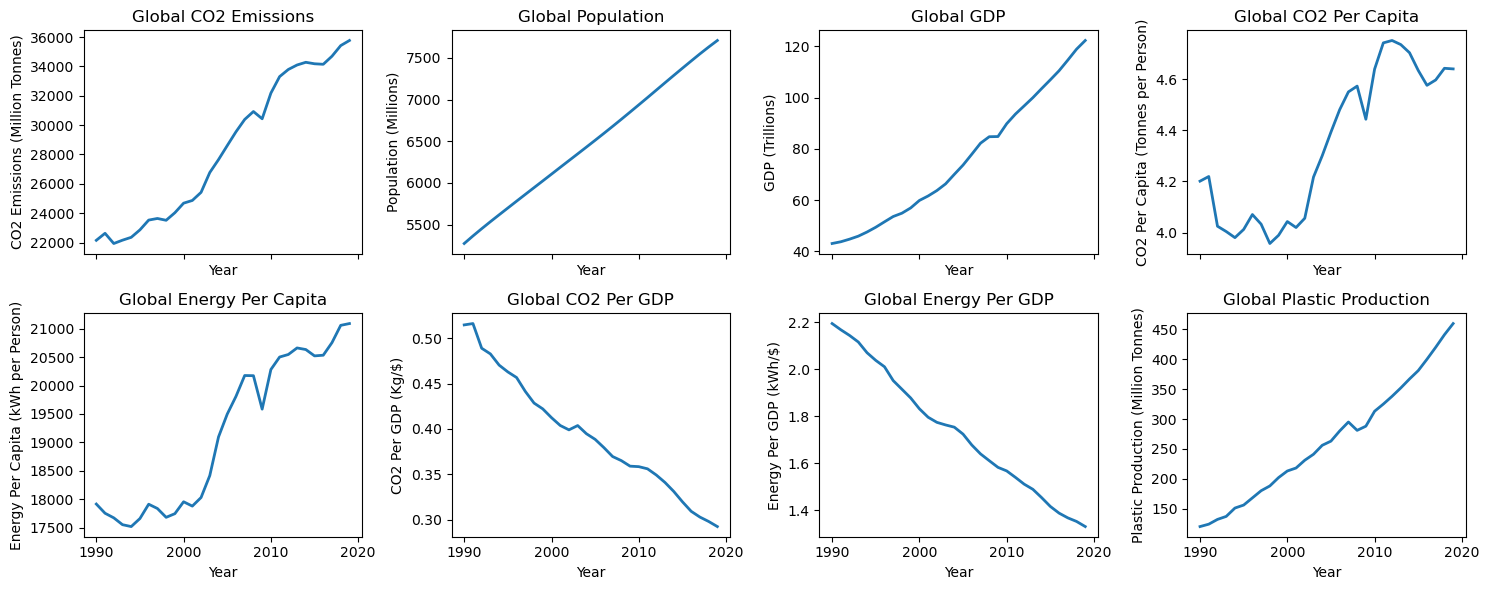

In [38]:
#Create seven subplots on 3 rows and 2 columns with a figsize of (12, 8)
fig, axes = plt.subplots(2,4, figsize=(15,6), sharex = True)
axes[0,0].plot(co2_plastics_global_data["year"], co2_plastics_global_data["total_co2_mt"],linewidth = 2)
axes[0,0].set_title("Global CO2 Emissions")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("CO2 Emissions (Million Tonnes)")
axes[0,1].plot(co2_plastics_global_data["year"], co2_plastics_global_data["population_global_millions"],linewidth = 2)
axes[0,1].set_title("Global Population")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Population (Millions)")
axes[0,2].plot(co2_plastics_global_data["year"], co2_plastics_global_data["gdp_global_trillions"],linewidth = 2)
axes[0,2].set_title("Global GDP")
axes[0,2].set_xlabel("Year")
axes[0,2].set_ylabel("GDP (Trillions)")
axes[0,3].plot(co2_plastics_global_data["year"], co2_plastics_global_data["co2_per_capita_global"],linewidth = 2)
axes[0,3].set_title("Global CO2 Per Capita")
axes[0,3].set_xlabel("Year")
axes[0,3].set_ylabel("CO2 Per Capita (Tonnes per Person)")
axes[1,0].plot(co2_plastics_global_data["year"], co2_plastics_global_data["energy_per_capita_global"],linewidth = 2)
axes[1,0].set_title("Global Energy Per Capita")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Energy Per Capita (kWh per Person)")
axes[1,1].plot(co2_plastics_global_data["year"], co2_plastics_global_data["co2_per_gdp_global"],linewidth = 2)
axes[1,1].set_title("Global CO2 Per GDP")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("CO2 Per GDP (Kg/$)")
axes[1,2].plot(co2_plastics_global_data["year"], co2_plastics_global_data["energy_per_gdp_global"],linewidth = 2)
axes[1,2].set_title("Global Energy Per GDP")
axes[1,2].set_xlabel("Year")
axes[1,2].set_ylabel("Energy Per GDP (kWh/$)")
axes[1,3].plot(co2_plastics_global_data["year"], co2_plastics_global_data["Total_Plastic_Production_Million_Tonnes"],linewidth = 2)
axes[1,3].set_title("Global Plastic Production")
axes[1,3].set_xlabel("Year")
axes[1,3].set_ylabel("Plastic Production (Million Tonnes)")
plt.tight_layout()
plt.show()

One of the very interesting insights we see from the above charts is that since 1990 to 2019, all numerical features in our summary dataset i.e. global population, global gdp, our target variable i.e. global co2 emissions, global co2 per capita, global energy per capita, and global plastic production have been increasing. However, global energy per gdp i.e the energy needed to produce 1 dollar worth of economic activity and global co2 per gdp which depends on energy usage have been decreasing. Ideally, if that is the case then our global co2 emissions should also have a decreasing trend. It seems like this decrease gets outweighed by the scale of growth of all other numerical features like population, gdp, plastic production etc.

For now, we will keep the co2 country/year dataset as our primary dataset for modeling and use the summary dataset as needed for global plastics data.

## 2.6 Save The Data <a id='2.6_Save_The_Data'></a>

In [39]:
# save the data to a new csv file
datapath = '../data/processed'
save_file(co2_data, 'co2_data_cleaned.csv', datapath)
save_file(co2_plastics_global_data, 'co2_plastics_global_data_cleaned.csv', datapath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\co2_data_cleaned.csv"
A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\co2_plastics_global_data_cleaned.csv"


## 2.7 Summary <a id='2.7_Summary'></a>

We performed the following steps for our data wrangling phase to tackle the co2 and plastics dataset from https://ourworldindata.org/  

1. We imported the co2 master dataset for country/year level data and made sure it had our required target indicator variable (co2 column) and also potential features to be used for our EDA and modeling ex. population, gdp, energy per capita etc.

2. We removed the unnecessary columns with features not needed for our analysis thus reducing our dataset from 79 to 10 columns. We then made sure that the data was present at the country/year level hierarchy and removed records that indicated hierarchy levels other than country level. We also checked which years had the least number of countries missing co2 data to ballpark our start time frame for analysis which we discovered to be 1990 (since very few countries, single digit count were missing this data).

3. Next, we imported our global plastics data. We ran a quick summary to check for the columns, record count and null values. We also ran summary stats and discovered that the timeframe for this dataset is from 1950 to 2019. Next, we made sure there were no duplicate records for any year since we only have one global record per year in this dataset. We also made sure there were no outliers for plastic production data in tonnes for the entire timeframe by plotting those values as a timeseries. We converted the plastic production in tonnes column to plastic production in million tonnes. Finally, we renamed the columns of the dataset and ran a quick summary again.

4. Next, we narrowed our co2 dataset for the timeframe of 1990 to 2019, since the maximum year available for plastics data was 2019 and very few countries had co2 data missing starting 1990. On this filtered dataset we ran a summary to identify the potential features with the most missing values and found that gdp columns had ~25% values missing. These missing values were for countries with a low population/small economy, conflict affected countries or offshore islands without an independent economy. Since these would have a negligible impact on the global gdp and emissions, we decided to go ahead and remove them from our dataset. From the filtered dataset only 1 record for a country had missing data for our target indicator co2 emissions.

5. We also created a merged global co2 + plastics dataset (1 record per year from 1990 to 2019) with our key indicator - total_co2_mt (co2 emissions in million tonnes) and following key features - population_global_millions, gdp_global_trillions, co2_per_capita_global, energy_per_capita_global, co2_per_gdp_global, energy_per_gdp_global, Total_Plastic_Production_Million_Tonnes and plotted them for trends and outlier identification. We noted some interesting facts that despite all other features increasing in value over the years including our target indicator of co2 emissions as expected, energy per gdp and co2 per gdp decreased potentially because of energy efficacy projects over the past decades and pressure on economies to reduce co2 pollution. However, since the scale of growth for other features like population, gdp, plastic production was a lot more than these two improvements, it seemed to have outweighed those benefits.

6. Finally, we saved our cleaned files - co2_data_cleaned and co2_plastics_global_data_cleaned to our data folder for our next phase, Exploratory Data Analaysis (EDA).